## 1. Embedding Serving API

텍스트를 벡터로 변환하는 임베딩 모델 API. OpenAI Embeddings 규격과 호환됩니다.

| 항목 | 값 |
|---|---|
| Endpoint | `POST {genos_url}/api/gateway/rep/serving/{serving_id}/v1/embeddings` |
| Headers | `Authorization: Bearer {genos_token}` |
| 모델 정보 조회 | `GET {genos_url}/api/gateway/rep/serving/{serving_id}/v1/models` |

<br>

| Parameter | Type | Required | Description |
|---|---|---|---|
| `input` | `list[str]` 또는 `str` | Y | 임베딩할 문자열. 리스트 권장 (예: `["문장1", "문장2"]`) |

**Response** — `data[i].embedding` 에 입력 순서대로 벡터(`list[float]`)가 담깁니다.<br>
bge-m3 기준 1024차원, 입력 1건당 최대 8192토큰(실제 상한은 `/v1/models` 의 `max_model_len` 확인).

**사전 준비** — 「모델서빙」에서 임베딩 모델의 `serving_id` 확인 → 서빙 상세 → 인증 키 생성으로 `genos_token` 발급.

In [ ]:
import requests
from pprint import pprint

genos_url   = "https://genos.genon.ai" # 도메인 주소
serving_id  = 10                       # 임베딩 모델서빙 ID
genos_token = "-인증키-"

headers = {"Authorization": f"Bearer {genos_token}"}

# 1) 모델 정보 조회 - serving_id/v1/models
models = requests.get(f"{genos_url}/api/gateway/rep/serving/{serving_id}/v1/models",
                      headers=headers, timeout=10).json()
print("모델:", [m["id"] for m in models["data"]], "(대표리비전ID)")
print("최대 입력 토큰 수:", models["data"][0]["max_model_len"])

# 2) 임베딩 호출
texts = ["현대캐피탈 자동차 할부 금리", "현대캐피탈 오토론 이자율", "오늘 점심 뭐 먹지"] # 배치입력 가능
res = requests.post(f"{genos_url}/api/gateway/rep/serving/{serving_id}/v1/embeddings",
                    headers=headers, json={"input": texts}, timeout=30)
response = res.json()
pprint(response)
embedding = response['data'][1]['embedding']
print("차원:", len(embedding))


In [ ]:
# OpenAI SDK를 통한 호출 가능
from openai import OpenAI

client = OpenAI(
    base_url="https://genos.genon.ai/api/gateway/rep/serving/10/v1",   # 주소만 교체
    api_key="-인증키-",                        # 키만 교체
)

models = client.models.list()                                          # GET /v1/models
res = client.embeddings.create(model="bge-m3",                         # POST /v1/embeddings
                               input=["현대캐피탈 자동차 할부 금리", "오늘 점심 뭐 먹지"])

print(res)
print(len(res.data), len(res.data[0].embedding), res.usage)

## 2. LLM Serving API

| 항목 | 값 |
|---|---|
| Endpoint | `POST {genos_url}/api/gateway/rep/serving/{serving_id}/v1/chat/completions` |
| Headers | `Authorization: Bearer {genos_token}` |
| 모델 정보 조회 | `GET .../v1/models` → `data[0].id` 가 모델명 |

<br>

| Parameter | Type | Required | Description |
|---|---|---|---|
| `messages` | `list[dict]` | Y | `[{"role": ..., "content": ...}]`<br>role 은 `system` / `user` / `assistant` |
| `model` | `str` | N | 모델명. 미지정 시 서빙 배포 모델 |
| `stream` | `bool` | N | SSE 스트리밍. 기본 `false` |
| `response_format` | `dict` | N | 구조화 출력.<br>`{"type": "json_schema", ...}` 또는 `{"type": "json_object"}` |

**Response** — `choices[0].message.content`.<br>
스트리밍 시 `data: {...}` 청크의 `choices[0].delta.content`, 종료는 `data: [DONE]`.

**사전 준비** — 「모델서빙」에서 LLM 의 `serving_id` 확인 → 서빙 상세 → 인증 키 생성 → 승인.

### 2.1 기본 호출

In [ ]:
import requests, json
from pprint import pprint

genos_url   = "https://genos.genon.ai"
serving_id  = 1183                     # LLM 모델서빙 ID
genos_token = "-인증키-"
headers     = {"Authorization": f"Bearer {genos_token}"}
url         = f"{genos_url}/api/gateway/rep/serving/{serving_id}"
body = {"messages": [{"role": "system", "content": "한 문장으로 답해."},
                     {"role": "user",   "content": "너는 무슨 모델이야"}]}  # openAI Chat Template을 따름.

# 일반 호출
res = requests.post(f"{url}/v1/chat/completions", headers=headers, json=body, timeout=60)
pprint(res.json())

In [ ]:
# OpenAI SDK를 통한 호출 가능
from openai import OpenAI

client = OpenAI(
    base_url="https://genos.genon.ai/api/gateway/rep/serving/1183/v1",   # 주소만 교체
    api_key="-인증키-",                        # 키만 교체
)

# 일반 호출 — 2장의 body 와 인자가 1:1
res = client.chat.completions.create(
    model="glm",                                              # 서빙에 모델이 묶여 있어 실질 무시
    messages=[{"role": "system", "content": "한 문장으로 답해."},
              {"role": "user",   "content": "너는 무슨 모델이야?"}],
    temperature=0.3, max_tokens=1024,
)
print(res.choices[0].message.content)

# 스트리밍 — SSE 파싱을 SDK 가 해주므로 delta.content 만 읽으면 끝
stream = client.chat.completions.create(model="glm", stream=True, max_tokens=256,
                                        messages=[{"role": "user", "content": "17 곱하기 23은? 한 문장으로."}])
for chunk in stream:
    if chunk.choices and chunk.choices[0].delta.content:
        print(chunk.choices[0].delta.content, end="", flush=True)

### 2.2 request body -> OpenAI Compatible하게 

In [ ]:
# OpenAI Compatible하게 제공.
# body 안에 들어가는 각종 파라미터를 동일하게 제공
# 단, vLLM 서빙이 뒷단에서 돌아가고 있으므로, vLLM이 제공하지 않거나 지원하지 않는 옵션은 무시되거나 에러남.
# 또한, 모델 자체가 못하는 기능을 요청하는 경우에도 마찬가지로 안 됨.

import requests
from pprint import pprint

genos_url   = "https://genos.genon.ai"
serving_id  = 1183
genos_token = "-인증키-"
headers     = {"Authorization": f"Bearer {genos_token}"}
url         = f"{genos_url}/api/gateway/rep/serving/{serving_id}"

body = {
    "messages": [
        {"role": "system", "content": "한 문장으로 답해."},
        {"role": "user",   "content": "너는 무슨 모델이야?"},
    ],
    "temperature": 0.3,          # 0~2. 낮을수록 일관된 답, 높을수록 다양한 답
    "max_tokens": 1024,          # 답변 최대 길이. 추론 모델은 생각 토큰도 포함되니 넉넉히
    "reasoning_effort": "low",   # low / medium / high. 추론 모델이 생각하는 양
}

res = requests.post(f"{url}/v1/chat/completions", headers=headers, json=body, timeout=60)
pprint(res.json())

### 2.2 stream 호출

In [ ]:
import json

res = requests.post(f"{url}/v1/chat/completions", headers=headers,
                    json={**body, "stream": True}, stream=True, timeout=60)

reasoning, answer = "", ""
phase = None                                   # 지금 흘러오는 게 생각인지 답변인지
for raw in res.iter_lines():
    if not raw:
        continue
    line = raw.decode("utf-8", "replace").strip()
    if not line.startswith("data:"):            # ": OPENROUTER PROCESSING" 같은 주석/keep-alive
        continue
    chunk = line[5:].strip()
    if chunk == "[DONE]":
        break
    try:
        obj = json.loads(chunk)
    except json.JSONDecodeError:
        continue

    for c in obj.get("choices", []):
        delta = c.get("delta") or {}
        r = delta.get("reasoning") or delta.get("reasoning_content")   # 생각 조각 (서빙마다 키 이름이 다름)
        t = delta.get("content")                                        # 답변 조각

        if r:
            if phase != "reasoning":
                print("\n[생각] ", end=""); phase = "reasoning"
            reasoning += r
            print(r, end="", flush=True)
        if t:
            if phase != "answer":
                print("\n\n[답변] ", end=""); phase = "answer"
            answer += t
            print(t, end="", flush=True)

print(f"\n\n--- reasoning {len(reasoning)}자 / answer {len(answer)}자")

### 2.3 이미지 입력 (VLM Serving)

In [ ]:
import base64, mimetypes, requests
from pprint import pprint

genos_url   = "https://genos.genon.ai"
serving_id  = 1174                                  # VLM 모델서빙 ID GLM 5.3-flash
genos_token = "-인증키-"
headers     = {"Authorization": f"Bearer {genos_token}"}
url         = f"{genos_url}/api/gateway/rep/serving/{serving_id}"

# 이미지 파일 -> "data:image/png;base64,...." 문자열
def image_to_data_url(path):
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

body = {
    "messages": [
        {
            "role": "user",
            "content": [                                   
                {"type": "image_url", "image_url": {"url": image_to_data_url("test.jpg")}},
                {"type": "text",      "text": "이 이미지에 무엇이 보이는지 한국어로 설명해줘."},
            ],
        }
    ],
    "temperature": 0.2,
    "max_tokens": 512,
}

res = requests.post(f"{url}/v1/chat/completions", headers=headers, json=body, timeout=120)
pprint(res.json())
print(res.json()["choices"][0]["message"]["content"])

## 3. Workflow Serving API

GenOS 에 배포된 워크플로우(Flowise기반)를 실행.

| 항목 | 값 |
|---|---|
| Endpoint | `POST {genos_url}/api/gateway/workflow/{workflow_id}/run/v2` |
| Headers | `Authorization: Bearer {genos_token}`<br>멀티턴 시 `x-genos-session-id: {chatId}` |
| 헬스체크 | `GET .../healthcheck` → `{"status": "ok"}` |

<br>

| Parameter | Type | Required | Description |
|---|---|---|---|
| `question` | `str` | Y | 사용자 입력 |
| `chatId` | `str` | N | 세션 ID(uuid4). 헤더 `x-genos-session-id` 와 같은 값 |
| `stream` | `bool` | N | 스트리밍. 기본 `false` |
| `overrideConfig` | `dict` | N | 워크플로우 변수(vars) 등 실행 설정 재정의 |

**Response** — 봉투 `{"code": 0, "errMsg": "success", "data": {...}}`

| data 필드 | 설명 |
|---|---|
| `text` | 최종 답변 |
| `sourceDocuments` | 참조 문서 배열 (선택) |
| `chatId` / `sessionId` | 세션 ID |

**주의** — 오류도 HTTP 200 으로 옵니다. 반드시 `code == 0` 을 확인하세요.

**사전 준비** — 「에이전트 > 워크플로우」에서 `workflow_id` 확인 → 상세 → 인증 키 생성 → 승인.

In [ ]:
import requests, json, re, uuid

genos_url = "https://genos.genon.ai"
workflow_id = 6589  # Flowise로 작성된 워크플로우
genos_token = "-인증키-"
url = f"{genos_url}/api/gateway/workflow/{workflow_id}"

session_id = str(uuid.uuid4())
headers = {
    "Authorization": f"Bearer {genos_token}",
    "x-genos-session-id": session_id}

In [ ]:
# 헬스체크
res = requests.get(f"{url}/healthcheck", headers=headers, timeout=10).json()
print(res)

In [ ]:
# 일반 호출
res = requests.post(f"{url}/run/v2", headers=headers,
                    json={"question": "1+1은?", "chatId": session_id}, timeout=120).json()
assert res["code"] == 0, res["errMsg"]
print("답변:", res["data"]["text"], "| 참조문서:", len(res["data"].get("sourceDocuments") or []))

In [ ]:
# 스트리밍 — 줄 앞머리 token: / result:
res = requests.post(f"{url}/run/v2", headers=headers, stream=True, timeout=120,
                    json={"question": "방금 답에 3을 더하면?", "chatId": session_id, "stream": True})
final = None
for line in res.iter_lines():
    if not line:
        continue
    s = line.decode()
    if m := re.match(r"^token: (.*)$", s, re.S):
        print(m.group(1), end="", flush=True)
    elif m := re.match(r"^result: (.*)$", s, re.S):
        final = json.loads(m.group(1))
print("\n최종:", final["text"] if final else None)


## 4. 코드서빙


| 항목 | 값 |
|---|---|
| Endpoint | `POST {genos_url}/api/gateway/code_serving/{code_serving_id}/{path}` (대표 리비전) |
| 리비전 지정 | `POST {genos_url}/api/gateway/code_serving/{code_serving_id}/{revision_id}/{path}` |
| Headers | `Authorization: Bearer {genos_token}` |
| 헬스체크 | `GET .../health` → `{"status": "ok"}` (startupProbe 가 호출, 없으면 배포 실패) |

<br>

| 용도 | path (컨테이너 서비스 탭에서 설정) | 요청 body | 응답 |
|---|---|---|---|
| 워크플로우 | `/chat` | `{"question": str, "stream": bool, "humanInput"?: dict}` — HITL 2턴째는 `question=""` + `humanInput` 만 옴 | `{"code": 0, "data": {"text": ...}}` 또는 SSE `data: {"event":"token","data":...}` |
| MCP 서버 | `/mcp/list`, `/mcp/call` | list: `{}` / call: `{"name": str, "arguments": dict}` | list: `{"code": 0, "data": {"tools": [...]}}` / call: `{"code": 0, "data": {"content": [{"type":"text","text":...}]}}` — **봉투 필수.** `code != 0` 또는 봉투 없음이면 GenOS 가 도구 목록을 빈 배열로 처리(에러 없이) |
| 전처리기 | `/preprocess` | `{"file_path", "params", "file_content_base64", "file_name", "file_size"}` | `{"code": 0, "data": [청크, ...]}` |

**Response** 
<br>
성공 `code == 0`, 실패도 HTTP 200 + `code != 0` 으로 오기때문에, 반드시 `code` 를 확인해야합니다.

**검증 값**
<br>
관리자 화면 「검증」 버튼 -> `question` / `file_path` 에 `__verify__` 를 보내고 있으며, 정상적인 검증이 완료되려면
코드서빙은 LLM 을 부르지 않고 `code 0` 으로 즉답해야 합니다.

**사전 준비** 
<br>
「서빙 > 코드 서빙」에서 `code_serving_id` 확인 -> 리비전 배포 -> 상세 -> 인증 키 생성 -> 승인.

### 4.1 기본 호출

In [ ]:
# 헬스체크
import requests

genos_url       = "https://genos.genon.ai"           # 도메인 주소
code_serving_id = 667                               # 코드서빙 ID(str, int 상관x)  --> 트래픽 분배설정을 반드시 할당해줘야함.
genos_token     = "-인증키-"
headers         = {"Authorization": f"Bearer {genos_token}"}
url             = f"{genos_url}/api/gateway/code_serving/{code_serving_id}"

res = requests.get(f"{url}/health", headers=headers, timeout=10)
print(res.status_code, res.json())                   # 200 {'status': 'ok'}

### 4.2 워크플로우형 코드서빙(/chat)

In [ ]:
# 일반 호출 — 응답 봉투 {"code": 0, "data": {"text": ...}}
import requests
from pprint import pprint

genos_url       = "https://genos.genon.ai"
code_serving_id = 667                               # 워크플로우형 코드서빙 ID
genos_token     = "-인증키-"
headers         = {"Authorization": f"Bearer {genos_token}"}
url             = f"{genos_url}/api/gateway/code_serving/{code_serving_id}"

body = {"question": "안녕!"}
res  = requests.post(f"{url}/chat", headers=headers, json=body, timeout=120).json()
pprint(res)
assert res["code"] == 0, res.get("errMsg")
print("답변:", res["data"]["text"])
print("참조문서:", len(res["data"].get("sourceDocuments") or []))

### 4.3 `/chat` 스트리밍 호출 (SSE)

`stream: true` 면 JSON 봉투 대신 SSE 로 옵니다. 프레임은 `data: {"event": ..., "data": ...}\n\n`. 답변 본문은 `token` 이벤트에만 실립니다 (`result` 이벤트는 핸들러가 없어 무시됨).

In [ ]:
# 스트리밍 — data: {"event": ..., "data": ...} 프레임. 이벤트 5종: token / sourceDocuments / action / error / end
import json

res = requests.post(f"{url}/chat", headers=headers, stream=True, timeout=120,
                    json={"question": "36개월 할부 금리는?", "stream": True})
answer, sources, interaction_id = "", [], None
for raw in res.iter_lines():
    line = raw.decode() if raw else ""
    if not line.startswith("data: "):                 # 'data: ' 뒤 공백 포함 — 그 외 줄은 규약상 버려진다
        continue
    ev = json.loads(line[6:])
    if ev["event"] == "token":
        answer += ev["data"]; print(ev["data"], end="", flush=True)
    elif ev["event"] == "sourceDocuments":
        sources = ev["data"]                          # 교체 방식 — 마지막 값이 최종 출처
    elif ev["event"] == "action":                     # HITL — 여기서 스트림이 끝나고 사용자 응답을 기다린다
        interaction_id = ev["data"]["interactionId"]
        print("\n[HITL]", [e["component"].get("title") for e in ev["data"]["elements"]])
    elif ev["event"] == "error":
        print("\n[오류]", ev["data"])
    elif ev["event"] == "end":
        break
print("\n출처:", [d["metadata"].get("file_name") for d in sources])

### 4.4 HITL — `action` 에 답하기 (`humanInput`)

`action` 이벤트를 받으면 스트림이 끝나고 사용자 선택을 기다립니다. 선택하면 **원 질문 없이** `humanInput` 만 실려 다시 호출됩니다. `interactionId` 로 상태를 이어가야 합니다. 규약 상세는 `계약정리.md` §5.


In [ ]:
# HITL 2턴째 — 사용자가 action 카드에서 선택하면 genportal 이 이 body 로 다시 부른다.
# question 은 "" 로 오고 humanInput 만 온다 → 코드서빙은 interactionId 로 저장해 둔 상태를 이어간다.
human_input = {"type": "proceed", "interactionId": interaction_id, "action": "submit",
               "values": {"selected": ["text2sql"]}}             # confirm 은 values 없이 submit/cancel
res = requests.post(f"{url}/chat", headers=headers, stream=True, timeout=120,
                    json={"question": "", "stream": True, "humanInput": human_input})
for raw in res.iter_lines():
    line = raw.decode() if raw else ""
    if line.startswith("data: "):
        ev = json.loads(line[6:])
        print(ev["event"], "→", str(ev["data"])[:100])

### 4.5 MCP 서버형 코드 서빙(/mcp/list, /mcp/call)

In [ ]:
# 도구 목록 — description 과 inputSchema 가 그대로 LLM 이 읽는 도구 설명이 됩니다
import requests
from pprint import pprint

genos_url       = "https://genos.genon.ai"
code_serving_id = 646                               # MCP 서버형 코드서빙 ID
genos_token     = "-인증키-"
headers         = {"Authorization": f"Bearer {genos_token}"}
url             = f"{genos_url}/api/gateway/code_serving/{code_serving_id}"

res   = requests.post(f"{url}/mcp/list", headers=headers, json={}, timeout=30).json()
tools = res.get("data", res).get("tools", [])        

# 정본은 {"code":0,"data":{"tools":[...]}}. 봉투 없는 {"tools":[...]} 는 이 셀에선 읽히지만
# GenOS 가 MCP 서버로 등록할 때는 code==0 봉투가 없으면 도구 목록을 빈 배열로 처리한다

for t in tools:
    print(f"- {t['name']}: {t.get('description', '')}")
    print("   required:", t.get("inputSchema", {}).get("required"))

In [ ]:
# 도구 실행 — {"name": 도구명, "arguments": {...}} → {"content": [{"type": "text", "text": ...}]}
import requests
from pprint import pprint

genos_url       = "https://genos.genon.ai"
code_serving_id = 646                               # MCP 서버형 코드서빙 ID
genos_token     = "-인증키-"
headers         = {"Authorization": f"Bearer {genos_token}"}
url             = f"{genos_url}/api/gateway/code_serving/{code_serving_id}"

body = {"name": "add", "arguments": {"a": 1, "b": 2}}
res  = requests.post(f"{url}/mcp/call", headers=headers, json=body, timeout=60).json()
pprint(res)
content = res.get("data", res).get("content", [])
print("결과:", content[0]["text"] if content else res.get("errMsg"))

## 5. MCP 호출


| 항목 | 값 |
|---|---|
| Endpoint | `POST {genos_url}/api/gateway/mcp/{mcp_server_id}/mcp` |
| Headers | `Authorization: Bearer {genos_token}` · `Accept: application/json, text/event-stream` · `MCP-Protocol-Version: 2025-06-18` · (initialize 이후) `Mcp-Session-Id` |
| 프로토콜 | JSON-RPC 2.0 — `{"jsonrpc": "2.0", "id": n, "method": ..., "params": {...}}` |

<br>

| method | params | result |
|---|---|---|
| `initialize` | `{"protocolVersion", "capabilities": {}, "clientInfo": {...}}` | 서버 정보. 응답 헤더 `Mcp-Session-Id` 를 이후 요청에 실음 |
| `tools/list` | 없음 | `{"tools": [{"name", "description", "inputSchema"}, ...]}` |
| `tools/call` | `{"name": str, "arguments": dict}` | `{"content": [{"type": "text", "text": ...}], "isError": bool}` |

**tool description 은 어디서 오나**
<br>코드서빙으로 배포한 MCP 서버는 도구 목록을 **DB 스냅샷이 아니라 코드서빙의 `/mcp/list` 응답에서 그대로** 가져옴.
<br>코드에 적은 `description` / `inputSchema` 를 가져오는 로직이라, **설명을 바꾸려면 코드를 고쳐 리비전을 재배포**하면 됨.

**사전 준비** 
<br>「도구 > MCP 서버」 에서 `mcp_server_id` 확인 → 상세 > 인증 키 생성 → 승인. (코드서빙 MCP 는 컨테이너 서비스 탭 > MCP 로 사용 > 경로 저장 후 목록에 나타남)

In [ ]:
# 공통 호출기 — initialize 로 세션을 열고(응답 헤더 Mcp-Session-Id 보관), JSON/SSE 응답을 같은 함수로 파싱
import requests, json

genos_url     = "https://genos.genon.ai"
mcp_server_id = 721                                  # MCP 서버 ID
genos_token   = "-인증키-"                            # MCP 서버 상세 > 인증 키 (코드서빙 인증키와 다름)
mcp_url       = f"{genos_url}/api/gateway/mcp/{mcp_server_id}/mcp"
headers       = {
    "Authorization": f"Bearer {genos_token}",
    "Content-Type": "application/json",
    "Accept": "application/json, text/event-stream",
    "MCP-Protocol-Version": "2025-06-18",            # 인식 목록: 2024-11-05 / 2025-03-26 / 2025-06-18 / 2025-11-25 / 2026-07-28
}
session = {"id": None}

def rpc(method, params=None, rpc_id=1):
    body = {"jsonrpc": "2.0", "id": rpc_id, "method": method}
    if params is not None:
        body["params"] = params
    h = dict(headers)
    if session["id"]:
        h["Mcp-Session-Id"] = session["id"]
    res = requests.post(mcp_url, headers=h, json=body, timeout=120)
    if res.headers.get("Mcp-Session-Id"):
        session["id"] = res.headers["Mcp-Session-Id"]
    text = res.text
    if "text/event-stream" in res.headers.get("content-type", ""):
        text = next(l[6:] for l in text.splitlines() if l.startswith("data: "))
    out = json.loads(text)
    if "error" in out:
        raise RuntimeError(out["error"])                 # -32022 미지원 버전 / -32020 헤더·body 버전 불일치
    return out["result"]

# initialize — GenOS 게이트웨이는 생략해도 tools/* 가 동작하지만 표준 흐름은 이걸 먼저 부른다
init = rpc("initialize", {"protocolVersion": "2025-06-18", "capabilities": {},
                          "clientInfo": {"name": "genos-edu", "version": "1.0"}})
print("서버:", init.get("serverInfo"), "| 세션:", session["id"])

# tools/list — LLM 이 보는 것과 동일한 description / inputSchema
for t in rpc("tools/list", rpc_id=2)["tools"]:
    req = ", ".join(t.get("inputSchema", {}).get("required", []))
    print(f"- {t['name']}({req}): {t.get('description', '')}")


In [ ]:
# tools/call — 도구 실행. result.content[*].text 에 결과, isError 로 실패 여부
result = rpc("tools/call", {"name": "add", "arguments": {"a": 1, "b": 2}}, rpc_id=3)
print(result)
print("결과:", "".join(c.get("text", "") for c in result.get("content", []) if isinstance(c, dict)))


## 6. VDB 검색


<br>(AI 드라이브도 내부적으로 VDB 하나이므로 방법이 같습니다.)

| 항목 | 값 |
|---|---|
| 주소 | `http://llmops-weaviate-service:8080` (**내부망** — 코드스페이스·코드서빙에서만 접근) |
| 인증 | `Authorization: Bearer {vdb_key}` — 「벡터DB 상세 > 인증키 탭」에서 발급. 해당 VDB 컬렉션에만 권한 |
| 인덱스 확인 | 벡터DB 상세 화면, 또는 `GET /v1/schema` (키에 권한 있는 컬렉션만 반환) |
| 검색 | `POST /v1/graphql` — `nearVector`(벡터) / `bm25`(키워드) / `hybrid`(혼합, `alpha` 0=키워드 1=벡터) |
| 질의 임베딩 | VDB 적재에 쓴 **같은 임베딩 서빙**(1장)으로 질문을 벡터화 |

청크 하나에 들어 있는 주요 프로퍼티:

| 프로퍼티 | 의미 |
|---|---|
| `text` / `ref_text` | 검색용 본문 / LLM 에 넘길 참조 본문 (암호화 VDB 면 암호문) |
| `file_name`, `file_path`, `i_page`, `e_page`, `n_page` | 출처 표시용 |
| `i_chunk_on_doc`, `n_chunk_of_doc` | 문서 내 청크 순번 |
| `doc_id` | 문서 ID (휴지통·활성 여부 판정 키) |
| `security_level` | 문서 보안등급 정수. AI 드라이브 파일 등급이 적재 시 기록되며, 드라이브 외 문서는 0(공개) |
| `ai_drive_node_path` | 드라이브 루트→파일의 노드 ID 체인(`/3/17/42/`). 폴더 단위 검색용 |
| `is_encrypted` | 본문 암호화 여부 |

**보안등급 주의** — 앱 채팅(Flowise)에서는 genportal-api 가 사용자 등급을 계산해 `security_level <= 등급` 필터를 자동으로 넣지만, **직접 검색에서는 필터를 직접 넣어야** 합니다. 사용자 유효 등급은 본인·관리그룹·역할에 부여된 등급의 최댓값(없으면 0)입니다.

In [ ]:
# 인증 확인 + 인덱스(컬렉션) 찾기 — 인덱스 이름을 모를 때
import requests

weaviate_url = "http://llmops-weaviate-service:8080"     # 내부망 주소 (코드스페이스에서 실행)
vdb_key      = "-인증키-"                          # 벡터DB 상세 > 인증키 탭
headers      = {"Authorization": f"Bearer {vdb_key}"}

res = requests.get(f"{weaviate_url}/v1/meta", headers=headers, timeout=15)
print("status:", res.status_code, "| weaviate:", res.json().get("version"))   # 401 이면 키가 잘못됨

schema = requests.get(f"{weaviate_url}/v1/schema", headers=headers, timeout=15).json()
for c in schema.get("classes", []):                     # 이 키가 권한을 가진 컬렉션만 나온다
    print("인덱스:", c["class"])
    print("  프로퍼티:", [p["name"] for p in c["properties"]])
    print("  커스텀 토큰 사전:", c.get("invertedIndexConfig", {}).get("tokenizerUserDict"))

### hybrid 검색 + 보안 필터

In [ ]:
# hybrid 검색 + 보안등급 필터 + 암호화 본문 복호화 — 앱 채팅이 자동으로 하는 것을 직접 재현 (weaviate-client v4, gRPC)
import os, base64, requests, weaviate
from weaviate.classes.init import Auth
from weaviate.classes.query import Filter, MetadataQuery

weaviate_host = "llmops-weaviate-service"                 # 내부망 (HTTP 8080 / gRPC 50051)
vdb_key       = "-인증키-"
vdb_index     = "K6960b01d5fff43779aa20707d51f902f"

genos_url      = "https://genos.genon.ai"
emb_serving_id = 10                                       # VDB 적재에 쓴 임베딩 서빙 ID (같은 모델이어야 함)
emb_token      = "-인증키-"
emb_headers    = {"Authorization": f"Bearer {emb_token}"}

question   = "근로자의 정의"
user_level = 2                                            # 검색하는 사용자의 보안등급
decrypt_key = os.getenv("G__ENCRYPT__KEY", "mnc")          # 암호화 VDB 복호화 키 — 운영자에게 받아 Env 로 주입 (코드에 적지 않음)

def decrypt_text(ciphertext: str, key: str) -> str:
    # preprocess-api AES256GCMCrypter 와 동일 규격: PBKDF2-SHA256(salt=genos, 100k) / base64([IV12][Tag16][암호문])
    from cryptography.hazmat.primitives import hashes
    from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
    from cryptography.hazmat.primitives.kdf.pbkdf2 import PBKDF2HMAC
    derived = PBKDF2HMAC(algorithm=hashes.SHA256(), length=32, salt=b"genos", iterations=100_000).derive(key.encode())
    raw = base64.b64decode(ciphertext)
    dec = Cipher(algorithms.AES(derived), modes.GCM(raw[:12], raw[12:28])).decryptor()
    return (dec.update(raw[28:]) + dec.finalize()).decode("utf-8")

# 1) 질문 임베딩 (1장과 동일)
res    = requests.post(f"{genos_url}/api/gateway/rep/serving/{emb_serving_id}/v1/embeddings",
                       headers=emb_headers, json={"input": [question]}, timeout=30).json()
vector = res["data"][0]["embedding"]

# 2) hybrid(벡터+키워드) + 필터
client = weaviate.connect_to_custom(http_host=weaviate_host, http_port=8080, http_secure=False,
                                    grpc_host=weaviate_host, grpc_port=50051, grpc_secure=False,
                                    auth_credentials=Auth.api_key(vdb_key))
try:
    col = client.collections.get(vdb_index)
    result = col.query.hybrid(
        query=question, vector=vector, alpha=0.5, limit=5,   # alpha 0=키워드만, 1=벡터만
        filters=Filter.by_property("security_level").less_or_equal(user_level),   # 속성 없는 컬렉션이면 이 줄 제거
        return_properties=["text", "file_name", "i_page", "doc_id", "security_level", "is_encrypted"],
        return_metadata=MetadataQuery(score=True),
    )
    for o in result.objects:
        p = o.properties
        text = p.get("text") or ""
        if p.get("is_encrypted") and text:                # 암호화 VDB 면 본문 복호화 (키가 틀리면 InvalidTag 예외)
            try:
                print("복호화 전", f" {text}")
                text = decrypt_text(text, decrypt_key)
            except Exception as e:
                text = f"[복호화 실패: {type(e).__name__} — G__ENCRYPT__KEY 확인] " + text[:40]
        print(f"[{o.metadata.score:.4f}] {p.get('file_name')} p.{int(p.get('i_page') or 0)} 등급 {int(p.get('security_level') or 0)}")
        print("   ", text[:120].replace("\n", " "), "...")
finally:
    client.close()

### 참고사항
<br>현재 AI 드라이브에서의 폴더 구조에 따라 적절한 Weaviate key를 발급할 절차가 front-end에는 없습니다.<br>
별도로 개발자 도구를 켜서 네트워크의 응답 json을 찾아서 https://genos.genon.ai/data/vectordb-source/detail/{vdb_id}로 상세페이지를 들어가서 발급받아야합니다.<br>
-> vdb read key를 UI에서 발급 받을 수 있도록 개선할 예정

In [ ]:
# 필터 조합 — AI 드라이브 특정 폴더 아래 + 파일명 부분 일치 (임베딩 없이 필터만)
import weaviate
from weaviate.classes.init import Auth
from weaviate.classes.query import Filter

weaviate_host = "llmops-weaviate-service"
vdb_key       = "-인증키-"
vdb_index     = "O745c847cd58b4fd093230395275f9d08"

folder_path  = "/2002/3499/"                                   # 드라이브 루트→폴더 노드 ID 체인 (ai_drive_node.id_path)
file_keyword = "N47"                                           # file_name에 N47이 들어간 청크만 검색하도록 하는 필터

client = weaviate.connect_to_custom(http_host=weaviate_host, http_port=8080, http_secure=False,
                                    grpc_host=weaviate_host, grpc_port=50051, grpc_secure=False,
                                    auth_credentials=Auth.api_key(vdb_key))
try:
    col = client.collections.get(vdb_index)
    result = col.query.fetch_objects(
        limit=10,
        filters=(Filter.by_property("ai_drive_node_path").like(f"{folder_path}*")   # AI 드라이브 문서가 아니면 이 줄 제거
                 & Filter.by_property("file_name").like(f"*{file_keyword}*")),
        return_properties=["file_name", "i_page", "doc_id", "security_level"],
    )
    print(f"{len(result.objects)}건")
    for o in result.objects:
        p = o.properties
        print(f"- {p.get('file_name')} p.{p.get('i_page')} doc_id={p.get('doc_id')} 등급 {p.get('security_level')}")
finally:
    client.close()

In [ ]:
import weaviate
from weaviate.classes.init import Auth

weaviate_host = "llmops-weaviate-service"
vdb_key       = "-인증키-"
vdb_index     = "O745c847cd58b4fd093230395275f9d08"

client = weaviate.connect_to_custom(http_host=weaviate_host, http_port=8080, http_secure=False,
                                    grpc_host=weaviate_host, grpc_port=50051, grpc_secure=False,
                                    auth_credentials=Auth.api_key(vdb_key))
try:
    col = client.collections.get(vdb_index)
    print("총 객체 수:", col.aggregate.over_all(total_count=True).total_count)
    sample = col.query.fetch_objects(limit=2, return_properties=["file_name", "is_encrypted", "text"])
    for o in sample.objects:
        p = o.properties
        print(p.get("file_name"), "| is_encrypted =", p.get("is_encrypted"), "| text 앞부분:", (p.get("text") or "")[:50])
finally:
    client.close()

### 커스텀 토큰 관련 주의 사항
**사용 전 확인** 
<br>암호화 드라이브 제약: 암호화 적재된 드라이브에서는 커스텀 토큰을 사용할 수 없습니다.
<br>
커스텀 토큰은 저장된 청크 텍스트를 kagome_kr 로 형태소 분석해 역인덱스(BM25) 를 만드는 방식으로 동작합니다. 암호화 적재된 드라이브는 청크 텍스트가 암호화된 상태로 저장되어 형태소 분석 자체가 불가능하므로, 토큰을 등록해도 검색에 반영되지 않습니다.

<br> 따라서 암호화가 필요한 데이터에는 커스텀 토큰 대신 벡터 유사도 검색을 사용해야합니다.

In [ ]:
# 키워드(BM25)만 — 커스텀 토큰 효과 확인용. 토큰 등록·재인덱싱 전후로 같은 질의를 비교한다
# 현재 위 셀 실행 겨과와 같이 text필드에 암호화가 적용된 상태라 (bm25 -> text필드에 대한 역색인 기준으로 동작)
import weaviate
from weaviate.classes.init import Auth
from weaviate.classes.query import MetadataQuery

weaviate_host = "llmops-weaviate-service"
vdb_key       = "-인증키-"
vdb_index     = "O745c847cd58b4fd093230395275f9d08"

keyword = "워크아웃 개시"                                        

client = weaviate.connect_to_custom(http_host=weaviate_host, http_port=8080, http_secure=False,
                                    grpc_host=weaviate_host, grpc_port=50051, grpc_secure=False,
                                    auth_credentials=Auth.api_key(vdb_key))
try:
    col = client.collections.get(vdb_index)

    # BM25 search의 경우 keyword로 넣은 단어가 한 청크에도 없으면 후보 0개
    result = col.query.bm25(query=keyword, query_properties=["text"], limit=5,
                            return_properties=["file_name", "i_page"],
                            return_metadata=MetadataQuery(score=True))
    for o in result.objects:  # 빈 리스트로 나와서 실행되지 않음. VDB의 text필드가 암호문이어서 한국어 키워드가 역색인에 없기 때문...
        print("test")
        print(f"{o.metadata.score:.4f}", o.properties.get("file_name"), "p.", o.properties.get("i_page"))
finally:
    client.close()

text필드에 대한 암호화 여부에 관하여 정리한 내용은 아래와 같습니다.

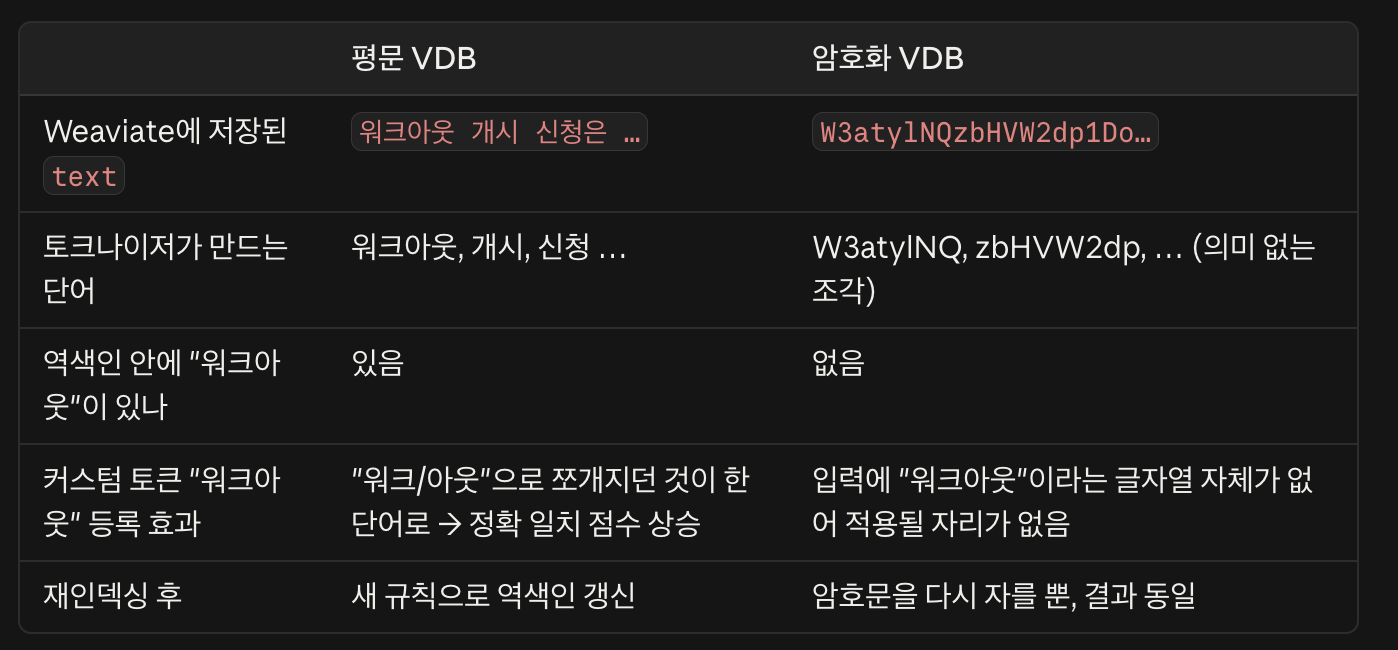

## 7. MinIO

워크플로우·코드서빙이 만든 파일(차트 HTML, 이미지, 표 CSV 등)을 GenOS 클러스터의 MinIO `temp` 버킷에 올리고 **임시 공개 URL(Presigned URL)** 을 받습니다. 이 URL 을 답변 마크다운에 넣으면 채팅 화면에서 이미지·차트가 바로 표시됩니다.

| 항목 | 값 |
|---|---|
| Endpoint | `POST http://llmops-cdn-api-service:8080/minio/upload/temp` (**내부망**) |
| Method | `multipart/form-data` |
| 인증 | 없음 (클러스터 내부 호출 전용) |

<br>

| Parameter | Type | Required | Description |
|---|---|---|---|
| `file` | file | Y | 업로드할 파일 객체 |
| `hostname` | str | Y | 사용자가 접속하는 GenOS 도메인. URL 의 호스트로 쓰임. §7 두 셀이 `genos.genon.ai` / `https://genos.genon.ai` 로 달랐는데 동작한 쪽(스킴 포함)으로 통일 |

**Response**
<br>`{"code": 0, "data": {"presigned_url": "https://.../temp/<uuid>.png?X-Amz-..."}}`. 파일명은 UUID 로 바뀌고 URL 은 만료 시간이 있습니다.

**채팅 노출 시 참고** 
<br>이미지는 `![제목](presigned_url)` 마크다운으로, HTML 차트는 URL 을 링크로 답변에 보통 활용합니다.

In [ ]:
# 파일 업로드 → Presigned URL
import requests

cdn_url  = "http://llmops-cdn-api-service:8080"           # 내부망 — 코드서빙/코드스페이스에서 실행
hostname = "https://genos.genon.ai"                       # 사용자가 접속하는 도메인 — §7 두 번째 셀과 동일하게 스킴 포함
path     = "test.jpg"                                     # 올릴 파일 (이미지·html·csv 등)

with open(path, "rb") as f:
    res = requests.post(f"{cdn_url}/minio/upload/temp",
                        files={"file": (path, f, "image/png")},
                        data={"hostname": hostname}, timeout=30).json()
assert res["code"] == 0, res
presigned_url = res["data"]["presigned_url"]
print(presigned_url)

In [ ]:
# 활용 예 — matplotlib 차트를 그려 올리고, 답변 마크다운에 이미지로 삽입
import requests
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

cdn_url  = "http://llmops-cdn-api-service:8080"   # 클러스터 내부 cdn-api
hostname = "https://genos.genon.ai"                # ★ 스킴(https://) 포함. 이 호스트 기준으로 서명된 URL 이 나온다

plt.figure(figsize=(5, 3))
plt.bar(["12m", "24m", "36m"], [4.9, 5.4, 5.9]); plt.title("Installment rate (%)")   # 기본 폰트에 한글이 없어 영어 라벨
plt.savefig("rate.png", bbox_inches="tight"); plt.close()

with open("rate.png", "rb") as f:
    res = requests.post(f"{cdn_url}/minio/upload/temp",
                        files={"file": ("rate.png", f, "image/png")},
                        data={"hostname": hostname}, timeout=30).json()
presigned_url = res["data"]["presigned_url"]       # https://genos.genon.ai/minio/temp/<uuid>.png?X-Amz-...  (2시간 유효)

answer_markdown = f"36개월 기준 금리는 5.9% 입니다.\n\n![할부 금리 비교]({presigned_url})"
print(answer_markdown)                             # 이 문자열을 답변(token)에 그대로 실으면 GenOS채팅에서는 이미지가 렌더됨.
print("다운로드 링크", presigned_url)

## 8. 서비스라우터

여러 서빙 리비전을 **하나의 고정 엔드포인트** 뒤에 묶은 라우터를 호출할 수 있습니다. 
<br>호출 주소는 라우터 이름으로 고정되고, 뒤의 리비전 교체·카나리·서킷 브레이커·가드레일은 라우터 정책에서 처리되므로 호출 코드는 바뀌지 않습니다.

| 라우터 유형 | Endpoint | 규약 |
|---|---|---|
| 서빙 - LLM / VLM | `POST {genos_url}/api/gateway/service-router/{endpoint}/v1/chat/completions` | OpenAI Chat (2장과 동일 body) |
| 서빙 - Embedding | `POST {genos_url}/api/gateway/service-router/{endpoint}/v1/embeddings` | OpenAI Embeddings (1장과 동일) |
| 서빙 - Rerank | `POST {genos_url}/api/gateway/service-router/{endpoint}/v1/rerank` | 리랭킹 |
| 코드 서빙 | `POST {genos_url}/api/gateway/service-router/{endpoint}/{path}` | 코드서빙이 정의한 path 그대로 |

<br>

| 항목 | 값 |
|---|---|
| Headers | `Authorization: Bearer {router_token}` — **라우터 인증키** (서빙 인증키 아님). 허용 IP·만료일·호출 한도를 라우터 단위로 관리 |
| `{endpoint}` | 라우터 생성 시 지정한 식별자 (영문 소문자·숫자·하이픈·언더스코어, 예: `hc-llm`) |

**주의** 
<br>라우터를 경유하면 **라우터의 가드레일만** 적용됩니다(대상 서빙 자체 가드레일은 무시). 
<br>추가적으로 코드서빙 가드레일은 이 라우터 플러그인이 유일한 적용 지점입니다.

**사전 준비** 
<br> 「배포 > 서비스 라우터」생성(유형·엔드포인트) → 타깃 리비전 추가 → 정책·플러그인 설정 → 인증 키 생성 → 승인.

In [ ]:
# LLM 라우터 — body 동일, URL 만 라우터로
import requests
from pprint import pprint

genos_url       = "https://genos.genon.ai"
router_endpoint = "hc"                               # 라우터 생성 시 지정한 엔드포인트
router_token    = "-인증키-"
headers         = {"Authorization": f"Bearer {router_token}"}
url             = f"{genos_url}/api/gateway/service-router/{router_endpoint}"

body = {"messages": [{"role": "system", "content": "한국어 한 문장으로 답해."},
                     {"role": "user",   "content": "서비스 라우터가 뭐야?"}],
        "temperature": 0.3, "max_tokens": 512}
res = requests.post(f"{url}/v1/chat/completions", headers=headers, json=body, timeout=60).json()
pprint(res)
print("답변:", res["choices"][0]["message"]["content"])
print("실제 응답 모델:", res.get("model"))               # 라우터가 고른 리비전의 모델. 카나리 중이면 호출마다 달라질 수 있음

In [ ]:
# 코드서빙 라우터 — 코드서빙이 정의한 path 그대로 (인증은 라우터 키)
res = requests.post(f"{url}/chat", headers=headers, json={"question": "안녕!"}, timeout=120).json()
print(res.get("code"), (res.get("data") or {}).get("text"))

## 9. 전처리기 호출

In [ ]:
# 코드스페이스 안에서 실행 — 전처리기 패키지 파드를 직접 호출 (게이트웨이·인증키 없음)
import requests, os

preprocessor_id = 456                                     # 전처리기 상세 URL 의 ID
base   = f"http://preprocessor-{preprocessor_id}:8080"

volume_id  = 268                                          # 터미널 `mount 2>/dev/null | grep " /workspace " | awk '{print $1}'` 에서 확인한 DEV/volume/<id>
local_path = "/workspace/seonggyunhong/hyundai-capital/api/남녀고용평등법.pdf"          # 코드스페이스 안 절대경로
pod_path   = local_path.replace("/workspace", f"/nfs-root/DEV/volume/{volume_id}", 1)   # 전처리기 파드가 보는 경로
assert os.path.exists(local_path), local_path

params = {
    "chunk_size": 400,          # 청크 최대 토큰 수 (yaml 기본값 대체)
    "chunk_mode": "split_only", # split_only=섹션 단위 / resize_all=chunk_size 까지 인접 섹션 병합
    "img_desc": 0, "table_desc": 0, "doc_summary": 0,   # VLM/LLM 호출 끔 — 청킹만 확인
}

print(requests.get(f"{base}/healthcheck", timeout=10).json())          # {'status': 'ok'}

res = requests.post(f"{base}/run", json={"file_path": pod_path, "params": params}, timeout=900).json()
assert res["code"] == 0, res.get("errMsg")
chunks = res["data"]

print(f"청크 수: {len(chunks)}  (chunk_size={params['chunk_size']}, chunk_mode={params['chunk_mode']})")
print("청크 키:", sorted(chunks[0].keys()))            # 어떤 메타데이터가 붙는지 한 번 확인

for i, c in enumerate(chunks):
    print("=" * 100)
    print(f"[청크 {i + 1}/{len(chunks)}]  페이지 {c.get('i_page')}~{c.get('e_page')}"
          f"  |  페이지 내 {c.get('i_chunk_on_page')}/{c.get('n_chunk_of_page')}번째"
          f"  |  {c.get('n_chars')}자 · {c.get('n_words')}단어 · {c.get('n_lines')}줄")
    print("-" * 100)
    print(c.get("text"))                                # 전체 본문. 자른 경계가 그대로 보인다
print("=" * 100)

## 10. 코드서빙 전처리기 호출

| 항목 | 값 |
|---|---|
| Endpoint | `POST {genos_url}/api/gateway/code_serving/{code_serving_id}/{revision_id}/preprocess` (경로는 컨테이너 서비스 탭 「전처리기로 사용」에 설정한 값, 기본 `/preprocess`) |
| Headers | `Authorization: Bearer {genos_token}` (코드서빙 인증키) |
| 검증 | 어드민 「검증」은 `{"file_path": "__verify__", "params": {}}` → 즉시 `code 0` |

<br>

| Parameter | Type | Required | Description |
|---|---|---|---|
| `file_path` | str | Y | 원본 경로 — **코드서빙 파드는 NFS 미보장으로 직접 read 불가** |
| `params` | dict | Y | 전처리기 등록 화면의 파라미터 (`chunk_size` 등) |
| `file_content_base64` | str | Y | preprocess-api 가 파일을 읽어 동봉. 이걸 디코드해 쓴다 |
| `file_name`, `file_size` | str, int | Y | 원본 파일명·바이트 수 |

**Response** — `{"code": 0, "errMsg": "success", "data": [GenOSVectorMeta, ...]}`. 청크 하나가 Weaviate 객체 하나. `extra='allow'` 라 커스텀 메타데이터를 자유롭게 더할 수 있다.

In [ ]:
# 코드서빙 전처리기를 직접 호출해 청킹 결과 확인 — preprocess-api 가 보내는 것과 같은 body 를 만든다
import base64, os, requests

genos_url       = "https://genos.genon.ai"
code_serving_id = 0                                  # 전처리기로 배포한 코드서빙 ID
revision_id     = 0                                  # 리비전 ID (대표 경로 가중치 0 이면 503 이라 리비전 핀 권장)
genos_token     = "-인증키-"
headers         = {"Authorization": f"Bearer {genos_token}"}
url             = f"{genos_url}/api/gateway/code_serving/{code_serving_id}/{revision_id}/preprocess"

# 검증 버튼이 보내는 것 — 즉시 code 0 이어야 한다
print(requests.post(url, headers=headers, json={"file_path": "__verify__", "params": {}}, timeout=30).json())

local_path = "남녀고용평등법.pdf"
with open(local_path, "rb") as f:
    content = f.read()
body = {
    "file_path": f"/nfs-root/docs/{os.path.basename(local_path)}",   # 참고용. 컨테이너는 이 경로를 읽지 않는다
    "params": {"chunk_size": 400, "chunk_overlap": 50},  # 해당 전처리기의 파라미터 옵션
    "file_content_base64": base64.b64encode(content).decode("ascii"),  # 사실상 필수는 이 값 하나
    "file_name": os.path.basename(local_path),  # 존재하면 해당 파일의 확장자 파악에 사용하고 없다면 기본값 .pdf를 붙힘
    "file_size": len(content),  # 없어도 정상적으로 요청이 전송됩니다.
}
res = requests.post(url, headers=headers, json=body, timeout=900).json()
assert res["code"] == 0, res.get("errMsg")
chunks = res["data"]
print(f"청크 {len(chunks)}개 | 키: {sorted(chunks[0].keys())}")
for c in chunks[:3]:
    print("-", f"p.{c.get('i_page')}~{c.get('e_page')}", (c.get("text") or "")[:80].replace("\n", " "))

## 11. A2A 에이전트 호출

Agent-to-Agent 프로토콜(JSON-RPC 2.0). **경로에 `/api/gateway` 접두어가 없습니다**

| 항목 | 값 |
|---|---|
| Agent Card | `GET {genos_url}/a2a/agents/{agent_card_id}/.well-known/agent.json` |
| 호출 | `POST {genos_url}/a2a/{agent_card_id}` |
| Headers | `Authorization: Bearer {genos_token}` (A2A 에이전트 상세 > 인증 키) |

<br>

| method | 설명 |
|---|---|
| `message/send` | 단발 호출. 답변은 `result.artifacts[*].parts`|
| `message/stream` | SSE 스트리밍. `event:` 줄 없이 `data:` 만 오므로 `data.result.kind`(status-update / artifact-update) 로 구분 |
| `tasks/send` · `tasks/sendSubscribe` | 레거시 이름 — 여전히 허용 |

멀티턴은 응답 `result.contextId` 를 다음 요청 `params.contextId` 에 넣습니다.

In [ ]:
import requests, json

genos_url     = "https://genos.genon.ai"
agent_card_id = 143                                  # A2A 에이전트 카드 ID (chit chat agent)
genos_token   = "-인증키-"
base          = f"{genos_url}/a2a"                     # ★ /api/gateway 접두어 없음 (실측)
headers       = {"Authorization": f"Bearer {genos_token}", "Content-Type": "application/json"}

# 1) Agent Card
card = requests.get(f"{base}/agents/{agent_card_id}/.well-known/agent.json", headers=headers, timeout=30).json()
print(card.get("name"), "|", card.get("description", "")[:60], "| skills:", [s.get("name") for s in card.get("skills", [])])

# 2) message/send
body = {"jsonrpc": "2.0", "id": "edu-1", "method": "message/send",
        "params": {"message": {"role": "user", "parts": [{"type": "text", "text": "36개월 할부 금리 알려줘"}]},
                   "timeout": 600}}
res = requests.post(f"{base}/{agent_card_id}", headers=headers, json=body, timeout=620).json()
assert "error" not in res, res.get("error")
result = res["result"]
parts = (result.get("status", {}).get("message", {}) or {}).get("parts") or \
        [p for a in result.get("artifacts", []) for p in a.get("parts", [])]
print("답변:", "".join(p.get("text", "") for p in parts if isinstance(p, dict)))
print("contextId:", result.get("contextId"), "| 상태:", (result.get("status") or {}).get("state"))

In [ ]:
# 3) message/stream — SSE 로 이벤트를 도착하는 대로
body["method"] = "message/stream"; body["id"] = "edu-2"
with requests.post(f"{base}/{agent_card_id}", headers=headers, json=body, stream=True, timeout=620) as res:
    event = None
    for line in res.iter_lines(decode_unicode=True):
        line = (line or "").strip()
        if line.startswith("event:"):
            event = line[6:].strip()
        elif line.startswith("data:"):                      # GenOS 는 event: 줄 없이 data: 만 보낸다
            raw = line[5:].strip()
            try:
                data = json.loads(raw)
            except json.JSONDecodeError:
                data = raw
            kind = event or (isinstance(data, dict) and (data.get("result") or {}).get("kind"))   # status-update / artifact-update
            print(kind, "→", json.dumps(data, ensure_ascii=False)[:160])
            event = None